In [1]:
from Simulation.mpc import *
from Simulation.system_functions import PolymerCSTR
from utils.helpers import *

## Initialize the system

In [2]:
# First initiate the system
# Parameters
Ad = 2.142e17           # h^-1
Ed = 14897              # K
Ap = 3.816e10           # L/(molh)
Ep = 3557               # K
At = 4.50e12            # L/(molh)
Et = 843                # K
fi = 0.6                # Coefficient
m_delta_H_r = -6.99e4   # j/mol
hA = 1.05e6             # j/(Kh)
rhocp = 1506            # j/(Kh)
rhoccpc = 4043          # j/(Kh)
Mm = 104.14             # g/mol
system_params = np.array([Ad, Ed, Ap, Ep, At, Et, fi, m_delta_H_r, hA, rhocp, rhoccpc, Mm])

In [3]:
# Design Parameters
CIf = 0.5888    # mol/L
CMf = 8.6981    # mol/L
Qi = 108.       # L/h
Qs = 459.       # L/h
Tf = 330.       # K
Tcf = 295.      # K
V = 3000.       # L
Vc = 3312.4     # L

system_design_params = np.array([CIf, CMf, Qi, Qs, Tf, Tcf, V, Vc])

In [4]:
# Steady State Inputs
Qm_ss = 378.    # L/h
Qc_ss = 471.6   # L/h

system_steady_state_inputs = np.array([Qc_ss, Qm_ss])

In [5]:
# Sampling time of the system
delta_t = 0.5 # 30 mins

In [6]:
# Initiate the CSTR for steady state values
cstr = PolymerCSTR(system_params, system_design_params, system_steady_state_inputs, delta_t)
steady_states={"ss_inputs":cstr.ss_inputs,
               "y_ss":cstr.y_ss}

## Loading the system matrices, min max scaling, and min max of the states

In [7]:
import os

In [8]:
dir_path = os.path.join(os.getcwd(), "Data")

In [9]:
from utils.td3_helpers import load_and_prepare_system_data

In [10]:
# Defining the range of setpoints for data generation
setpoint_y = np.array([[3.2, 321],
                       [4.5, 325]])
u_min = np.array([71.6, 78])
u_max = np.array([870, 670])

system_data = load_and_prepare_system_data(steady_states=steady_states, setpoint_y=setpoint_y, u_min=u_min, u_max=u_max)

In [11]:
A_aug = system_data["A_aug"]
B_aug = system_data["B_aug"]
C_aug = system_data["C_aug"]

In [12]:
data_min = system_data["data_min"]
data_max = system_data["data_max"]

In [13]:
min_max_states = {'max_s': np.array([256.79686253, 256.01560603,  48.99447186, 144.79949103,
          2.82199733,   3.14014989,   2.78866348,   3.71691422,
          6.2029936 ]),
                  'min_s': np.array([ -272.28060121, -1112.33972595,   -76.63993491,  -608.60327886,
           -3.94399122,    -3.93115257,    -2.9532091 ,    -4.06547624,
          -28.25906582])}

In [14]:
y_sp_scaled_deviation = system_data["y_sp_scaled_deviation"]

In [15]:
b_min = system_data["b_min"]
b_max = system_data["b_max"]

In [16]:
min_max_dict = system_data["min_max_dict"]
min_max_dict["x_max"] = np.array([256.79686253, 256.01560603,  48.99447186, 144.79949103,
          2.82199733,   3.14014989,   2.78866348,   3.71691422,
          6.2029936 ])
min_max_dict["x_min"] = np.array([ -272.28060121, -1112.33972595,   -76.63993491,  -608.60327886,
           -3.94399122,    -3.93115257,    -2.9532091 ,    -4.06547624,
          -28.25906582])

In [17]:
from utils.scaling_helpers import apply_min_max, reverse_min_max

In [84]:
# Setpoints in deviation form
inputs_number = int(B_aug.shape[1])
y_sp_scenario = np.array([[4.5, 324],
                          [3.4, 321]])

y_sp_scenario = (apply_min_max(y_sp_scenario, data_min[inputs_number:], data_max[inputs_number:])
                 - apply_min_max(steady_states["y_ss"], data_min[inputs_number:], data_max[inputs_number:]))
n_tests = 200
set_points_len = 400
TEST_CYCLE = [False, False]
warm_start = 10
ACTOR_FREEZE = 10 * set_points_len
warm_start_plot = warm_start * 2 * set_points_len + ACTOR_FREEZE

In [19]:
# Observer Gain
poles = np.array(np.array([0.44619852, 0.33547649, 0.36380595, 0.70467118, 0.3562966,
                           0.42900673, 0.4228262 , 0.96916776, 0.91230187]))
L = compute_observer_gain(A_aug, C_aug, poles)

The system is observable.


C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Simulation\mpc.py:114: UserWarning: Convergence was not reached after maxiter iterations.
You asked for a tolerance of 0.001, we got 0.9999999422182038.
  obs_gain_calc = signal.place_poles(A.T, C.T, desired_poles, method='KNV0')


In [20]:
def make_reward_fn_relative_QR(
        data_min, data_max, n_inputs,
        k_rel, band_floor_phys,
        Q_diag, R_diag,
        tau_frac=0.7,
        gamma_out=0.5, gamma_in=0.5,
        beta=5.0, gate="geom", lam_in=1.0,
        bonus_kind="exp", bonus_k=12.0, bonus_p=0.6, bonus_c=20.0,
):
    """
    Reward with relative tracking bands.

    data_min, data_max : arrays for [u_min..., y_min...], [u_max..., y_max...]
    n_inputs           : number of inputs (so outputs start at index n_inputs)
    k_rel              : per-output relative tolerance factors (same length as outputs)
    band_floor_phys    : per-output minimum band in physical units
    Q_diag, R_diag     : quadratic weights (same as before)
    """

    data_min = np.asarray(data_min, float)
    data_max = np.asarray(data_max, float)
    dy = np.maximum(data_max[n_inputs:] - data_min[n_inputs:], 1e-12)  # phys range for each y

    k_rel = np.asarray(k_rel, float)
    band_floor_phys = np.asarray(band_floor_phys, float)
    Q_diag = np.asarray(Q_diag, float)
    R_diag = np.asarray(R_diag, float)

    # floor in *scaled* coordinates (used if y_sp_phys is not provided)
    band_floor_scaled = band_floor_phys / np.maximum(dy, 1e-12)

    def _sigmoid(x):
        x = np.clip(x, -60.0, 60.0)
        return 1.0 / (1.0 + np.exp(-x))

    def _phi(z, kind=bonus_kind, k=bonus_k, p=bonus_p, c=bonus_c):
        z = np.clip(z, 0.0, 1.0)
        if kind == "linear":
            return 1.0 - z
        if kind == "quadratic":
            return (1.0 - z) ** 2
        if kind == "exp":
            return (np.exp(-k * z) - np.exp(-k)) / (1.0 - np.exp(-k))
        if kind == "power":
            return 1.0 - np.power(z, p)
        if kind == "log":
            return np.log1p(c * (1.0 - z)) / np.log1p(c)
        raise ValueError("unknown bonus kind")

    def reward_fn(e_scaled, du_scaled, y_sp_phys=None):
        """
        e_scaled : output error in scaled deviation space  (same as before)
        du_scaled: input move in scaled deviation space    (same as before)
        y_sp_phys: current setpoint in *physical* units (array len = n_outputs)
        """

        e_scaled = np.asarray(e_scaled, float)
        du_scaled = np.asarray(du_scaled, float)

        # ----- dynamic band based on setpoint -----
        if y_sp_phys is None:
            # fallback: just use the floor
            band_scaled = band_floor_scaled
        else:
            y_sp_phys_arr = np.asarray(y_sp_phys, float)
            # band_phys_i = max(k_rel_i * |y_sp_i|, band_floor_phys_i)
            band_phys = np.maximum(k_rel * np.abs(y_sp_phys_arr), band_floor_phys)
            band_scaled = band_phys / np.maximum(dy, 1e-12)

        tau_scaled = tau_frac * band_scaled

        # ----- inside/outside gate -----
        abs_e = np.abs(e_scaled)
        s_i = _sigmoid((band_scaled - abs_e) / np.maximum(tau_scaled, 1e-12))

        if gate == "prod":
            w_in = float(np.prod(s_i, dtype=np.float64))
        elif gate == "mean":
            w_in = float(np.mean(s_i))
        elif gate == "geom":
            w_in = float(np.prod(s_i, dtype=np.float64) ** (1.0 / len(s_i)))
        else:
            raise ValueError("gate must be 'prod'|'mean'|'geom'")

        # ----- core quadratic costs -----
        err_quad = np.sum(Q_diag * (e_scaled ** 2))
        err_eff = (1.0 - w_in) * err_quad + w_in * (lam_in * err_quad)
        move = np.sum(R_diag * (du_scaled ** 2))

        # ----- linear penalties around band edge -----
        slope_at_edge = 2.0 * Q_diag * band_scaled

        overflow = np.maximum(abs_e - band_scaled, 0.0)
        lin_out = (1.0 - w_in) * np.sum(gamma_out * slope_at_edge * overflow)

        inside_mag = np.minimum(abs_e, band_scaled)
        lin_in = w_in * np.sum(gamma_in * slope_at_edge * inside_mag)

        # ----- bonus near zero error -----
        qb2 = Q_diag * (band_scaled ** 2)
        z = abs_e / np.maximum(band_scaled, 1e-12)
        phi = _phi(z)
        bonus = w_in * beta * np.sum(qb2 * phi)

        # ----- total reward -----
        return (-(err_eff + move + lin_out + lin_in) + bonus)*0.01

    params = dict(
        k_rel=k_rel,
        band_floor_phys=band_floor_phys,
        band_floor_scaled=band_floor_scaled,
        Q_diag=Q_diag,
        R_diag=R_diag,
        tau_frac=tau_frac,
        gamma_out=gamma_out,
        gamma_in=gamma_in,
        beta=beta,
        gate=gate,
        lam_in=lam_in,
        bonus_kind=bonus_kind,
        bonus_k=bonus_k,
        bonus_p=bonus_p,
        bonus_c=bonus_c,
    )
    return params, reward_fn


## Reward configuration
n_inputs = 2

dy = data_max[n_inputs:] - data_min[n_inputs:]
y_sp_nom = 0.5 * (data_min[n_inputs:] + data_max[n_inputs:])

k_rel = np.array([0.003, 0.0003])
band_floor_phys = np.array([0.006, 0.07])

band_phys = np.maximum(k_rel * np.abs(y_sp_nom), band_floor_phys)

scale_factor = 1.0  # use 2.0 for [-1, 1] scaling, 1.0 for [0, 1]
band_scaled = scale_factor * band_phys / dy

q0 = 1.4
Q_diag = q0 / np.maximum(band_scaled ** 2, 1e-12)

print("dy:", dy)
print("y_sp_nom:", y_sp_nom)
print("band_phys:", band_phys)
print("band_scaled:", band_scaled)
print("Q_diag:", Q_diag)
Q_diag = np.array([518., 90.])  # rounded from the band-based calculation
R_diag = np.array([90., 90.])  # move cost for du_scaled ~ 0.02

n_inputs = 2

print("Band scaled are:")

params, reward_fn = make_reward_fn_relative_QR(
    data_min, data_max, n_inputs,
    k_rel, band_floor_phys,
    Q_diag, R_diag,
    tau_frac=0.7,
    gamma_out=0.5, gamma_in=0.5,
    beta=7.0, gate="geom", lam_in=1.0,
    bonus_kind="exp", bonus_k=12.0, bonus_p=0.6, bonus_c=20.0,
)
print(params)

dy: [0.22165278 0.78153727]
y_sp_nom: [  3.83915067 323.21371982]
band_phys: [0.01151745 0.09696412]
band_scaled: [0.05196169 0.12406845]
Q_diag: [518.51529284  90.95055189]
Band scaled are:
{'k_rel': array([0.003 , 0.0003]), 'band_floor_phys': array([0.006, 0.07 ]), 'band_floor_scaled': array([0.02706937, 0.08956707]), 'Q_diag': array([518.,  90.]), 'R_diag': array([90., 90.]), 'tau_frac': 0.7, 'gamma_out': 0.5, 'gamma_in': 0.5, 'beta': 7.0, 'gate': 'geom', 'lam_in': 1.0, 'bonus_kind': 'exp', 'bonus_k': 12.0, 'bonus_p': 0.6, 'bonus_c': 20.0}


In [21]:
def make_reward_fn_relative_QR(
        data_min, data_max, n_inputs,
        k_rel, band_floor_phys,
        Q_diag, R_diag,
        tau_frac=0.7,
        gamma_out=0.5, gamma_in=0.5,
        beta=5.0, gate="geom", lam_in=1.0,
        bonus_kind="exp", bonus_k=12.0, bonus_p=0.6, bonus_c=20.0,
):
    """
    Reward with relative tracking bands.

    data_min, data_max : arrays for [u_min..., y_min...], [u_max..., y_max...]
    n_inputs           : number of inputs (so outputs start at index n_inputs)
    k_rel              : per-output relative tolerance factors (same length as outputs)
    band_floor_phys    : per-output minimum band in physical units
    Q_diag, R_diag     : quadratic weights (same as before)
    """

    data_min = np.asarray(data_min, float)
    data_max = np.asarray(data_max, float)
    dy = np.maximum(data_max[n_inputs:] - data_min[n_inputs:], 1e-12)  # phys range for each y

    k_rel = np.asarray(k_rel, float)
    band_floor_phys = np.asarray(band_floor_phys, float)
    Q_diag = np.asarray(Q_diag, float)
    R_diag = np.asarray(R_diag, float)

    # floor in *scaled* coordinates (used if y_sp_phys is not provided)
    band_floor_scaled = band_floor_phys / np.maximum(dy, 1e-12)

    def _sigmoid(x):
        x = np.clip(x, -60.0, 60.0)
        return 1.0 / (1.0 + np.exp(-x))

    def _phi(z, kind=bonus_kind, k=bonus_k, p=bonus_p, c=bonus_c):
        z = np.clip(z, 0.0, 1.0)
        if kind == "linear":
            return 1.0 - z
        if kind == "quadratic":
            return (1.0 - z) ** 2
        if kind == "exp":
            return (np.exp(-k * z) - np.exp(-k)) / (1.0 - np.exp(-k))
        if kind == "power":
            return 1.0 - np.power(z, p)
        if kind == "log":
            return np.log1p(c * (1.0 - z)) / np.log1p(c)
        raise ValueError("unknown bonus kind")

    def reward_fn(e_scaled, du_scaled, y_sp_phys=None):
        """
        e_scaled : output error in scaled deviation space  (same as before)
        du_scaled: input move in scaled deviation space    (same as before)
        y_sp_phys: current setpoint in *physical* units (array len = n_outputs)
        """

        e_scaled = np.asarray(e_scaled, float)
        du_scaled = np.asarray(du_scaled, float)

        # ----- dynamic band based on setpoint -----
        if y_sp_phys is None:
            # fallback: just use the floor
            band_scaled = band_floor_scaled
        else:
            y_sp_phys_arr = np.asarray(y_sp_phys, float)
            # band_phys_i = max(k_rel_i * |y_sp_i|, band_floor_phys_i)
            band_phys = np.maximum(k_rel * np.abs(y_sp_phys_arr), band_floor_phys)
            band_scaled = band_phys / np.maximum(dy, 1e-12)

        tau_scaled = tau_frac * band_scaled

        # ----- inside/outside gate -----
        abs_e = np.abs(e_scaled)
        s_i = _sigmoid((band_scaled - abs_e) / np.maximum(tau_scaled, 1e-12))

        if gate == "prod":
            w_in = float(np.prod(s_i, dtype=np.float64))
        elif gate == "mean":
            w_in = float(np.mean(s_i))
        elif gate == "geom":
            w_in = float(np.prod(s_i, dtype=np.float64) ** (1.0 / len(s_i)))
        else:
            raise ValueError("gate must be 'prod'|'mean'|'geom'")

        # ----- core quadratic costs -----
        err_quad = np.sum(Q_diag * (e_scaled ** 2))
        err_eff = (1.0 - w_in) * err_quad + w_in * (lam_in * err_quad)
        move = np.sum(R_diag * (du_scaled ** 2))

        # ----- linear penalties around band edge -----
        slope_at_edge = 2.0 * Q_diag * band_scaled

        overflow = np.maximum(abs_e - band_scaled, 0.0)
        lin_out = (1.0 - w_in) * np.sum(gamma_out * slope_at_edge * overflow)

        inside_mag = np.minimum(abs_e, band_scaled)
        lin_in = w_in * np.sum(gamma_in * slope_at_edge * inside_mag)

        # ----- bonus near zero error -----
        qb2 = Q_diag * (band_scaled ** 2)
        z = abs_e / np.maximum(band_scaled, 1e-12)
        phi = _phi(z)
        bonus = w_in * beta * np.sum(qb2 * phi)

        # ----- total reward -----
        return -(err_eff + move)

    params = dict(
        k_rel=k_rel,
        band_floor_phys=band_floor_phys,
        band_floor_scaled=band_floor_scaled,
        Q_diag=Q_diag,
        R_diag=R_diag,
        tau_frac=tau_frac,
        gamma_out=gamma_out,
        gamma_in=gamma_in,
        beta=beta,
        gate=gate,
        lam_in=lam_in,
        bonus_kind=bonus_kind,
        bonus_k=bonus_k,
        bonus_p=bonus_p,
        bonus_c=bonus_c,
    )
    return params, reward_fn


## Reward configuration
n_inputs = 2

dy = data_max[n_inputs:] - data_min[n_inputs:]
y_sp_nom = 0.5 * (data_min[n_inputs:] + data_max[n_inputs:])

k_rel = np.array([0.003, 0.0003])
band_floor_phys = np.array([0.006, 0.07])

band_phys = np.maximum(k_rel * np.abs(y_sp_nom), band_floor_phys)

scale_factor = 1.0  # use 2.0 for [-1, 1] scaling, 1.0 for [0, 1]
band_scaled = scale_factor * band_phys / dy

q0 = 1.4
Q_diag = q0 / np.maximum(band_scaled ** 2, 1e-12)

print("dy:", dy)
print("y_sp_nom:", y_sp_nom)
print("band_phys:", band_phys)
print("band_scaled:", band_scaled)
print("Q_diag:", Q_diag)
Q_diag = np.array([5., 1.])  # rounded from the band-based calculation
R_diag = np.array([1., 1.])  # move cost for du_scaled ~ 0.02

n_inputs = 2

print("Band scaled are:")

params, reward_fn_mpc = make_reward_fn_relative_QR(
    data_min, data_max, n_inputs,
    k_rel, band_floor_phys,
    Q_diag, R_diag,
    tau_frac=0.7,
    gamma_out=0.5, gamma_in=0.5,
    beta=7.0, gate="geom", lam_in=1.0,
    bonus_kind="exp", bonus_k=12.0, bonus_p=0.6, bonus_c=20.0,
)
print(params)

dy: [0.22165278 0.78153727]
y_sp_nom: [  3.83915067 323.21371982]
band_phys: [0.01151745 0.09696412]
band_scaled: [0.05196169 0.12406845]
Q_diag: [518.51529284  90.95055189]
Band scaled are:
{'k_rel': array([0.003 , 0.0003]), 'band_floor_phys': array([0.006, 0.07 ]), 'band_floor_scaled': array([0.02706937, 0.08956707]), 'Q_diag': array([5., 1.]), 'R_diag': array([1., 1.]), 'tau_frac': 0.7, 'gamma_out': 0.5, 'gamma_in': 0.5, 'beta': 7.0, 'gate': 'geom', 'lam_in': 1.0, 'bonus_kind': 'exp', 'bonus_k': 12.0, 'bonus_p': 0.6, 'bonus_c': 20.0}


In [157]:
import os
import pickle
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from utils.scaling_helpers import apply_min_max, reverse_min_max


class CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("numpy._core"):
            module = "numpy.core" + module[len("numpy._core"):]
        return super().find_class(module, name)


def load_pkl(path):
    with open(path, "rb") as f:
        return CompatUnpickler(f).load()


def resolve_pickle_path(path, preferred_name="input_data.pkl"):
    if os.path.isdir(path):
        candidate = os.path.join(path, preferred_name)
        if os.path.exists(candidate):
            return candidate

        pkl_files = sorted(
            [os.path.join(path, x) for x in os.listdir(path) if x.endswith(".pkl")]
        )
        if not pkl_files:
            raise FileNotFoundError(f"No .pkl file found in directory: {path}")
        return pkl_files[0]
    return path


def load_saved_run(path, preferred_name="input_data.pkl"):
    pkl_path = resolve_pickle_path(path, preferred_name=preferred_name)
    d = load_pkl(pkl_path)
    d["_loaded_from"] = pkl_path
    return d


def make_output_dir(directory=None, prefix_name="plot"):
    if directory is None:
        directory = os.getcwd()
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = os.path.join(directory, prefix_name, timestamp)
    os.makedirs(out_dir, exist_ok=True)
    return out_dir


def save_figure(fig, out_dir, stem, save_pdf=True):
    fig.savefig(os.path.join(out_dir, f"{stem}.png"), dpi=300, bbox_inches="tight")
    if save_pdf:
        fig.savefig(os.path.join(out_dir, f"{stem}.pdf"), bbox_inches="tight")
    plt.close(fig)


PLOT_COLORS = {
    "RL2": "#1f77ff",      # brighter blue
    "RL1": "#ff8c1a",      # brighter orange
    "OF-MPC": "#2ca02c",   # strong green
    "SP": "#ff1f1f",       # bright red for visibility
    "warm_start": "#a9a9a9",
    "reward": "#7a3db8",
}

INPUT_COLORS = [
    "#4E79A7",  # blue
    "#F28E2B",  # orange
    "#59A14F",  # green
    "#E15759",  # red
    "#76B7B2",  # teal
    "#EDC948",  # yellow
    "#B07AA1",  # purple
    "#FF9DA7",  # pink
]

def canonical_controller_label(label):
    s = str(label).strip().upper()
    s = s.replace(" ", "").replace("_", "").replace("--", "-")

    if "RL2" in s:
        return "RL2"
    if "RL1" in s:
        return "RL1"
    if "OFMPC" in s or "MPC" in s:
        return "OF-MPC"
    if s in {"SP", "SETPOINT"}:
        return "SP"
    return str(label)


def controller_color(label, fallback=None):
    key = canonical_controller_label(label)
    if key in PLOT_COLORS:
        return PLOT_COLORS[key]

    if fallback is not None and fallback in PLOT_COLORS:
        return PLOT_COLORS[fallback]

    return "#4E79A7"


def set_paper_style():
    plt.style.use("default")
    mpl.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 16,
        "font.weight": "bold",
        "axes.labelsize": 19,
        "axes.labelweight": "bold",
        "axes.titlesize": 18,
        "axes.titleweight": "bold",
        "axes.linewidth": 1.8,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.30,
        "legend.fontsize": 14,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "legend.edgecolor": "0.75",
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "lines.linewidth": 2.8
    })


def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.set_major_locator(mtick.MaxNLocator(6))
    ax.xaxis.set_minor_locator(mtick.AutoMinorLocator(2))
    ax.yaxis.set_major_locator(mtick.MaxNLocator(6))
    ax.yaxis.set_minor_locator(mtick.AutoMinorLocator(2))
    ax.tick_params(axis="both", which="major", width=1.4, length=5)
    ax.tick_params(axis="both", which="minor", width=1.1, length=3)

    for label in ax.get_xticklabels():
        label.set_fontweight("bold")
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")


def bold_legend(ax, *args, **kwargs):
    leg = ax.legend(*args, **kwargs)
    if leg is not None:
        for txt in leg.get_texts():
            txt.set_fontweight("bold")
    return leg


def add_subplot_tag(ax, tag):
    ax.text(
        0.01, 0.97, tag,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=14,
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.5)
    )


def as_2d(a):
    a = np.asarray(a, float)
    if a.ndim == 1:
        a = a.reshape(-1, 1)
    return a


def get_first_array(d, keys):
    for key in keys:
        if key in d and d[key] is not None:
            return np.asarray(d[key], float)
    return None


def infer_n_inputs(d, default=2):
    if "n_inputs" in d:
        return int(d["n_inputs"])
    return int(default)


def as_ysp_steps(y_sp):
    y_sp = np.asarray(y_sp, float)
    if y_sp.ndim != 2:
        raise ValueError("y_sp must be 2D.")
    if y_sp.shape[0] < y_sp.shape[1]:
        return y_sp.T
    return y_sp


def get_output_line(d):
    y = get_first_array(d, ["y_rl", "y_mpc", "y"])
    if y is None:
        raise KeyError("Could not find output trajectory in pickle.")
    return as_2d(y)


def get_output_steps(d):
    y = get_output_line(d)
    u = get_first_array(d, ["u_rl", "u_mpc", "u"])
    if u is not None and y.shape[0] == u.shape[0] + 1:
        return y[1:, :]
    return y


def get_input_steps(d):
    u = get_first_array(d, ["u_rl", "u_mpc", "u"])
    if u is None:
        raise KeyError("Could not find input trajectory in pickle.")
    return as_2d(u)


def get_delta_t(d):
    if "delta_t" not in d:
        raise KeyError("delta_t not found in pickle.")
    return float(d["delta_t"])

def default_output_labels(n_out):
    return tuple([f"Output {i + 1}" for i in range(n_out)])

def default_input_labels(n_in):
    return tuple([f"Input {i + 1}" for i in range(n_in)])


def get_warm_start_window_hours(d):
    ws = np.atleast_1d(np.asarray(d.get("warm_start_plot", []), float)).ravel()
    if ws.size == 0:
        return None
    dt = get_delta_t(d)
    ws = ws * dt
    return float(np.min(ws)), float(np.max(ws))


def y_sp_phys_from_saved_run(d, n_inputs=None, n_steps=None):
    if n_inputs is None:
        n_inputs = infer_n_inputs(d)

    y_sp_dev_scaled = as_ysp_steps(d["y_sp"])
    data_min = np.asarray(d["data_min"], float)
    data_max = np.asarray(d["data_max"], float)

    y_ss_scaled = apply_min_max(
        np.asarray(d["steady_states"]["y_ss"], float),
        data_min[n_inputs:], data_max[n_inputs:]
    )

    y_sp_abs_scaled = y_sp_dev_scaled + y_ss_scaled
    y_sp_phys = reverse_min_max(
        y_sp_abs_scaled,
        data_min[n_inputs:], data_max[n_inputs:]
    )
    y_sp_phys = np.asarray(y_sp_phys, float)

    if n_steps is not None:
        n = int(min(n_steps, y_sp_phys.shape[0]))
        y_sp_phys = y_sp_phys[-n:, :]
    return y_sp_phys


def tail_line_from_steps_or_line(arr, n_steps):
    arr = np.asarray(arr, float)
    n_steps = int(n_steps)

    if arr.shape[0] >= n_steps + 1:
        return arr[-(n_steps + 1):, :]
    if arr.shape[0] == n_steps:
        return np.vstack([arr[:1, :], arr])

    pad = (n_steps + 1) - arr.shape[0]
    return np.vstack([np.full((pad, arr.shape[1]), np.nan), arr])


def stack_1d(curves):
    T = int(max(len(c) for c in curves))
    X = np.full((len(curves), T), np.nan, dtype=float)
    for i, c in enumerate(curves):
        c = np.asarray(c, float).ravel()
        X[i, :len(c)] = c
    return X

def get_saved_warm_start_window_hours(d):
    if "warm_start_plot" not in d or d["warm_start_plot"] is None:
        return None

    ws = np.atleast_1d(np.asarray(d["warm_start_plot"], float)).ravel()
    if ws.size == 0:
        return None

    dt = get_delta_t(d)

    # warm_start_plot is stored as indices/steps, convert to hours
    ws = ws * dt

    return float(np.min(ws)), float(np.max(ws))


def normalize_warm_start_span(
    d,
    warm_start_span="saved",
    warm_start_in_steps=False
):
    """
    Returns (t0, t1) in hours, or None.

    warm_start_span:
      - "saved": use d["warm_start_plot"] if it exists
      - None: no shading
      - (a, b): user-specified span
    """
    if warm_start_span is None:
        return None

    if isinstance(warm_start_span, str):
        if warm_start_span.lower() == "saved":
            return get_saved_warm_start_window_hours(d)
        raise ValueError("warm_start_span string must be 'saved' or None.")

    if isinstance(warm_start_span, (tuple, list)) and len(warm_start_span) == 2:
        a, b = float(warm_start_span[0]), float(warm_start_span[1])

        if warm_start_in_steps:
            dt = get_delta_t(d)
            a = a * dt
            b = b * dt

        if b < a:
            a, b = b, a
        return a, b

    raise ValueError(
        "warm_start_span must be None, 'saved', or a tuple/list like (start, end)."
    )


def add_warm_start_patch(ax, warm_start_span, color=None, alpha=0.85):
    if warm_start_span is None:
        return
    if color is None:
        color = "0.75"
    ax.axvspan(
        float(warm_start_span[0]),
        float(warm_start_span[1]),
        facecolor=color,
        edgecolor="0.55",
        linewidth=0.8,
        alpha=alpha,
        zorder=0
    )


def band_stats(X, band="minmax"):
    mu = np.nanmean(X, axis=0)
    if band == "minmax":
        lo = np.nanmin(X, axis=0)
        hi = np.nanmax(X, axis=0)
    elif band == "p25p75":
        lo = np.nanpercentile(X, 25, axis=0)
        hi = np.nanpercentile(X, 75, axis=0)
    else:
        raise ValueError("band must be 'minmax' or 'p25p75'")
    return mu, lo, hi


def step_rewards_from_yu(y_phys_full, u_phys, meta_dict, reward_fn, n_inputs=2):
    data_min = np.asarray(meta_dict["data_min"], float)
    data_max = np.asarray(meta_dict["data_max"], float)

    y_phys_full = np.asarray(y_phys_full, float)
    u_phys = np.asarray(u_phys, float)

    if y_phys_full.shape[0] == u_phys.shape[0] + 1:
        y_phys = y_phys_full[1:, :]
    else:
        y_phys = y_phys_full

    y_sp_dev_scaled_all = as_ysp_steps(meta_dict["y_sp"])
    n_steps = int(min(y_phys.shape[0], u_phys.shape[0], y_sp_dev_scaled_all.shape[0]))

    y_phys = y_phys[-n_steps:, :]
    u_phys = u_phys[-n_steps:, :]
    y_sp_dev_scaled_all = y_sp_dev_scaled_all[-n_steps:, :]

    y_scaled = apply_min_max(y_phys, data_min[n_inputs:], data_max[n_inputs:])
    u_scaled = apply_min_max(u_phys, data_min[:n_inputs], data_max[:n_inputs])

    y_ss_scaled = apply_min_max(
        np.asarray(meta_dict["steady_states"]["y_ss"], float),
        data_min[n_inputs:], data_max[n_inputs:]
    )
    y_sp_scaled = y_sp_dev_scaled_all + y_ss_scaled
    e_scaled = y_scaled - y_sp_scaled

    du_scaled = np.zeros_like(u_scaled)
    du_scaled[1:, :] = u_scaled[1:, :] - u_scaled[:-1, :]

    y_sp_phys = reverse_min_max(y_sp_scaled, data_min[n_inputs:], data_max[n_inputs:])

    r = np.zeros(n_steps, dtype=float)
    for t in range(n_steps):
        r[t] = float(reward_fn(e_scaled[t], du_scaled[t], y_sp_phys=y_sp_phys[t]))
    return r


def episode_avg_from_steps(r_step, ep_len):
    r_step = np.asarray(r_step, float).ravel()
    ep_len = int(ep_len)
    n_eps = int(len(r_step) // ep_len)
    out = []
    for e in range(n_eps):
        a = e * ep_len
        b = (e + 1) * ep_len
        out.append(float(np.mean(r_step[a:b])))
    return np.asarray(out, float)


def get_eval_abs_error_scaled(d, n_inputs=2, eval_len=800, sub_len=400, settle_len=80):
    data_min = np.asarray(d["data_min"], float)
    data_max = np.asarray(d["data_max"], float)

    y_steps = get_output_steps(d)
    y_sp_dev_scaled = as_ysp_steps(d["y_sp"])

    n_steps = int(min(y_steps.shape[0], y_sp_dev_scaled.shape[0]))
    y_steps = y_steps[-n_steps:, :]
    y_sp_dev_scaled = y_sp_dev_scaled[-n_steps:, :]

    eval_len = int(min(eval_len, n_steps))
    y_eval = y_steps[-eval_len:, :]
    y_sp_dev_eval = y_sp_dev_scaled[-eval_len:, :]

    y_scaled = apply_min_max(y_eval, data_min[n_inputs:], data_max[n_inputs:])
    y_ss_scaled = apply_min_max(
        np.asarray(d["steady_states"]["y_ss"], float),
        data_min[n_inputs:], data_max[n_inputs:]
    )
    y_sp_scaled = y_sp_dev_eval + y_ss_scaled

    e_abs = np.abs(y_scaled - y_sp_scaled)

    sub_len = int(min(sub_len, eval_len // 2))
    settle_len = int(min(settle_len, sub_len))

    a = e_abs[:sub_len, :]
    b = e_abs[sub_len:sub_len + sub_len, :]

    a_ss = a[-settle_len:, :]
    b_ss = b[-settle_len:, :]
    return a_ss, b_ss


def plot_outputs_from_saved_run(
    run_path,
    out_dir=None,
    prefix_name="polymer_outputs",
    ylabels=None,
    rl_label="RL",
    setpoint_label="Setpoint",
    warm_start_label="Warm-start",
    start_plot_idx=0,
    tail_windows=(400, 800),
    warm_start_span="saved",
    warm_start_in_steps=False,
    save_pdf=True
):
    set_paper_style()
    d = load_saved_run(run_path)

    if out_dir is None:
        out_dir = make_output_dir(prefix_name=prefix_name)

    y_line = get_output_line(d)

    if ylabels is None:
        ylabels = default_output_labels(y_line.shape[1])
    if len(ylabels) != y_line.shape[1]:
        raise ValueError("Length of ylabels must match number of outputs.")
    y_steps = get_output_steps(d)
    dt = get_delta_t(d)
    n_steps = y_steps.shape[0]
    y_sp = y_sp_phys_from_saved_run(d, n_steps=n_steps)

    ws = normalize_warm_start_span(
        d,
        warm_start_span=warm_start_span,
        warm_start_in_steps=warm_start_in_steps
    )

    t_line = np.linspace(0.0, n_steps * dt, n_steps + 1)
    t_step = t_line[:-1]
    i0 = int(max(0, start_plot_idx))

    fig, axs = plt.subplots(y_line.shape[1], 1, figsize=(8.3, 6.0), sharex=True)
    if y_line.shape[1] == 1:
        axs = [axs]

    for j, ax in enumerate(axs):
        add_warm_start_patch(ax, ws)

        ax.plot(
            t_line[i0:], y_line[i0:, j],
            color=controller_color(rl_label, fallback="RL2"), lw=2.6, zorder=2
        )
        ax.step(
            t_step[i0:], y_sp[i0:, j],
            where="post",
            color=PLOT_COLORS["SP"],
            ls="-.",
            lw=1.2,
            alpha=0.55,
            zorder=5
        )

        ax.set_ylabel(ylabels[j])
        clean_axes(ax)
        # add_subplot_tag(ax, f"({chr(97 + j)})")

        if j == 0:
            handles = [
                Line2D([0], [0], color=controller_color(rl_label, fallback="RL2"), lw=2.6, label=rl_label),
                Line2D([0], [0], color=PLOT_COLORS["SP"], lw=2.2, ls="-.", label=setpoint_label)
            ]
            if ws is not None:
                handles.append(
                    Patch(
                        facecolor=PLOT_COLORS["warm_start"],
                        edgecolor="none",
                        alpha=0.55,
                        label=warm_start_label
                    )
                )
            bold_legend(ax, handles=handles, loc="best", ncol=len(handles))

    axs[-1].set_xlabel("Time (h)")
    save_figure(fig, out_dir, "fig_outputs_full", save_pdf=save_pdf)

    for W in tail_windows:
        W = int(min(W, n_steps))
        if W <= 5:
            continue

        y_tail = tail_line_from_steps_or_line(y_line, W)
        y_sp_tail = y_sp[-W:, :]
        t_line_tail = np.linspace(0.0, W * dt, W + 1)
        t_step_tail = t_line_tail[:-1]

        fig, axs = plt.subplots(y_line.shape[1], 1, figsize=(7.8, 5.5), sharex=True)
        if y_line.shape[1] == 1:
            axs = [axs]

        for j, ax in enumerate(axs):
            ax.plot(
                t_line_tail, y_tail[:, j],
                color=controller_color(rl_label, fallback="RL2"), lw=2.6
            )
            ax.step(
                t_step_tail, y_sp_tail[:, j],
                where="post",
                color=PLOT_COLORS["SP"],
                ls="-.",
                lw=2.6,
                alpha=0.95,
                zorder=5
            )
            ax.set_ylabel(ylabels[j])
            clean_axes(ax)
            # add_subplot_tag(ax, f"({chr(97 + j)})")

            if j == 0:
                bold_legend(ax,
                    handles=[
                        Line2D([0], [0], color=controller_color(rl_label, fallback="RL2"), lw=2.6, label=rl_label),
                        Line2D([0], [0], color=PLOT_COLORS["SP"], lw=2.2, ls="-.", label=setpoint_label)
                    ],
                    loc="best",
                    ncol=2
                )

        axs[-1].set_xlabel("Time (h)")
        save_figure(fig, out_dir, f"fig_outputs_last_{W}", save_pdf=save_pdf)

    return out_dir

def plot_saved_run_reward_vs_mpc(
    run_path,
    mpc_path,
    reward_fn,
    out_dir=None,
    prefix_name="reward_vs_mpc",
    rl_label="RL",
    mpc_label="OF-MPC",
    start_episode=1,
    mode="auto",
    n_inputs=2,
    save_pdf=True
):
    set_paper_style()

    d_rl = load_saved_run(run_path)
    d_mpc = load_saved_run(mpc_path)

    if out_dir is None:
        out_dir = make_output_dir(prefix_name=prefix_name)

    avg_rewards_rl = np.asarray(d_rl["avg_rewards"], float).ravel()
    ep_len = int(d_rl["time_in_sub_episodes"])

    y_mpc = get_output_line(d_mpc)
    u_mpc = get_input_steps(d_mpc)

    r_step_mpc = step_rewards_from_yu(
        y_mpc,
        u_mpc,
        d_rl,
        reward_fn,
        n_inputs=n_inputs
    )
    r_ep_mpc = episode_avg_from_steps(r_step_mpc, ep_len=ep_len)

    start_episode = int(max(1, start_episode))
    i0 = start_episode - 1

    x_rl = np.arange(start_episode, len(avg_rewards_rl) + 1)
    y_rl = avg_rewards_rl[i0:]

    if mode == "auto":
        if len(r_ep_mpc) <= 2 and len(y_rl) > len(r_ep_mpc):
            mode_use = "nominal"
        else:
            mode_use = "disturbance"
    else:
        mode_use = mode

    fig, ax = plt.subplots(figsize=(7.2, 4.4))

    ax.plot(
        x_rl,
        y_rl,
        color=controller_color(rl_label, fallback="RL2"),
        lw=2.8,
        marker="o",
        ms=4.0,
        label=rl_label
    )

    if mode_use == "nominal":
        mpc_const = float(r_ep_mpc[-1]) if len(r_ep_mpc) else np.nan
        ax.hlines(
            mpc_const,
            xmin=x_rl[0],
            xmax=x_rl[-1],
            color=controller_color(mpc_label, fallback="OF-MPC"),
            lw=2.6,
            ls="--",
            label=mpc_label
        )
    else:
        r_mpc_plot = r_ep_mpc[i0:i0 + len(y_rl)]
        n = min(len(x_rl), len(r_mpc_plot))
        ax.plot(
            x_rl[:n],
            r_mpc_plot[:n],
            color=controller_color(mpc_label, fallback="OF-MPC"),
            lw=2.6,
            ls="--",
            marker="s",
            ms=3.8,
            label=mpc_label
        )

    ax.set_xlabel("Episode")
    ax.set_ylabel("Average reward")
    clean_axes(ax)
    bold_legend(ax, loc="best")
    save_figure(fig, out_dir, f"fig_reward_vs_mpc_{mode_use}", save_pdf=save_pdf)

    return out_dir

def plot_saved_run_eval_vs_mpc(
    run_path,
    mpc_path,
    out_dir=None,
    prefix_name="eval_vs_mpc",
    rl_label="RL",
    mpc_label="OF-MPC",
    setpoint_label="Setpoint",
    ylabels=None,
    eval_steps=None,
    n_inputs=2,
    save_pdf=True
):
    set_paper_style()

    d_rl = load_saved_run(run_path)
    d_mpc = load_saved_run(mpc_path)

    if out_dir is None:
        out_dir = make_output_dir(prefix_name=prefix_name)

    y_rl = get_output_line(d_rl)
    y_mpc = get_output_line(d_mpc)
    dt = get_delta_t(d_rl)

    if eval_steps is None:
        eval_steps = int(d_rl["time_in_sub_episodes"])
    eval_steps = int(eval_steps)

    y_sp = y_sp_phys_from_saved_run(d_rl, n_inputs=n_inputs)

    n_out = y_rl.shape[1]
    if ylabels is None:
        ylabels = default_output_labels(n_out)
    if len(ylabels) != n_out:
        raise ValueError("Length of ylabels must match number of outputs.")

    n_steps = int(min(
        eval_steps,
        y_sp.shape[0],
        y_rl.shape[0] - 1,
        y_mpc.shape[0] - 1
    ))
    if n_steps <= 5:
        raise ValueError("Evaluation window too small after alignment.")

    y_rl_tail = tail_line_from_steps_or_line(y_rl, n_steps)
    y_mpc_tail = tail_line_from_steps_or_line(y_mpc, n_steps)
    y_sp_tail = y_sp[-n_steps:, :]

    t_line = np.linspace(0.0, n_steps * dt, n_steps + 1)
    t_step = t_line[:-1]

    fig, axs = plt.subplots(n_out, 1, figsize=(8.2, 5.8), sharex=True)
    if n_out == 1:
        axs = [axs]

    for j, ax in enumerate(axs):
        ax.plot(
            t_line,
            y_rl_tail[:, j],
            color=controller_color(rl_label, fallback="RL2"),
            lw=2.8,
            label=rl_label
        )
        ax.plot(
            t_line,
            y_mpc_tail[:, j],
            color=controller_color(mpc_label, fallback="OF-MPC"),
            lw=2.6,
            ls="--",
            label=mpc_label
        )
        ax.step(
            t_step,
            y_sp_tail[:, j],
            where="post",
            color=PLOT_COLORS["SP"],
            lw=2.9,
            ls="-.",
            zorder=5,
            label=setpoint_label
        )

        ax.set_ylabel(ylabels[j], fontweight="bold")
        clean_axes(ax)

        if j == 0:
            bold_legend(ax, loc="best", ncol=3)

    axs[-1].set_xlabel("Time (h)", fontweight="bold")
    save_figure(fig, out_dir, "fig_eval_outputs_vs_mpc", save_pdf=save_pdf)

    return out_dir


def plot_inputs_from_saved_run(
    run_path,
    out_dir=None,
    prefix_name="polymer_inputs",
    ulabels=None,
    save_pdf=True
):
    set_paper_style()
    d = load_saved_run(run_path)

    if out_dir is None:
        out_dir = make_output_dir(prefix_name=prefix_name)

    u = get_input_steps(d)
    if ulabels is None:
        ulabels = default_input_labels(u.shape[1])
    if len(ulabels) != u.shape[1]:
        raise ValueError("Length of ulabels must match number of inputs.")
    dt = get_delta_t(d)
    n_steps = u.shape[0]
    t_step = np.linspace(0.0, n_steps * dt, n_steps, endpoint=False)

    input_colors = [INPUT_COLORS[j % len(INPUT_COLORS)] for j in range(u.shape[1])]

    fig, axs = plt.subplots(u.shape[1], 1, figsize=(7.8, 5.4), sharex=True)
    if u.shape[1] == 1:
        axs = [axs]

    for j, ax in enumerate(axs):
        ax.step(
            t_step, u[:, j],
            where="post",
            color=input_colors[j % len(input_colors)],
            lw=2.5
        )
        ax.set_ylabel(ulabels[j])
        clean_axes(ax)
        # add_subplot_tag(ax, f"({chr(97 + j)})")

    axs[-1].set_xlabel("Time (h)")
    save_figure(fig, out_dir, "fig_inputs_full", save_pdf=save_pdf)
    return out_dir


def plot_rewards_from_saved_run(
    run_path,
    out_dir=None,
    prefix_name="polymer_rewards",
    start_episode=1,
    save_pdf=True
):
    set_paper_style()
    d = load_saved_run(run_path)

    if out_dir is None:
        out_dir = make_output_dir(prefix_name=prefix_name)

    avg_rewards = np.asarray(d["avg_rewards"], float).ravel()
    i0 = max(0, int(start_episode) - 1)
    x = np.arange(i0 + 1, len(avg_rewards) + 1)

    fig, ax = plt.subplots(figsize=(7.0, 4.2))
    ax.plot(
        x,
        avg_rewards[i0:],
        color=PLOT_COLORS["reward"],
        lw=2.5,
        marker="o",
        ms=4.0
    )
    ax.set_xlabel("Episode")
    ax.set_ylabel("Average reward")
    clean_axes(ax)
    save_figure(fig, out_dir, "fig_rewards", save_pdf=save_pdf)
    return out_dir


def plot_disturbances_from_saved_run(
    run_path,
    out_dir=None,
    prefix_name="polymer_disturbances",
    last_window=None,
    save_pdf=True
):
    set_paper_style()
    d = load_saved_run(run_path)

    if out_dir is None:
        out_dir = make_output_dir(prefix_name=prefix_name)

    dist = d.get("dist", None)
    if dist is None:
        return out_dir

    dt = get_delta_t(d)

    if isinstance(dist, dict) and all(k in dist for k in ["qi", "qs", "ha"]):
        qi = np.asarray(dist["qi"], float).ravel()
        qs = np.asarray(dist["qs"], float).ravel()
        ha = np.asarray(dist["ha"], float).ravel()
        n = min(len(qi), len(qs), len(ha))

        qi = qi[:n]
        qs = qs[:n]
        ha = ha[:n]

        def _plot_block(qi_use, qs_use, ha_use, stem):
            m = len(qi_use)
            t = np.linspace(0.0, m * dt, m, endpoint=False)

            fig, axs = plt.subplots(3, 1, figsize=(7.8, 6.3), sharex=True)

            axs[0].plot(t, qi_use, color="tab:blue", lw=2.4, label=r"$Q_i$")
            axs[1].plot(t, qs_use, color="tab:orange", lw=2.4, label=r"$Q_s$")
            axs[2].plot(t, ha_use, color="tab:green", lw=2.4, label=r"$hA$")

            ylabels = (r"$Q_i$ (L/h)", r"$Q_s$ (L/h)", r"$hA$ (J/K h)")
            for j, ax in enumerate(axs):
                ax.set_ylabel(ylabels[j])
                clean_axes(ax)
                # add_subplot_tag(ax, f"({chr(97 + j)})")
                bold_legend(ax, loc="best")

            axs[-1].set_xlabel("Time (h)")
            save_figure(fig, out_dir, stem, save_pdf=save_pdf)

        _plot_block(qi, qs, ha, "fig_disturbances_full")

        if last_window is not None:
            W = int(min(last_window, n))
            if W > 5:
                _plot_block(qi[-W:], qs[-W:], ha[-W:], f"fig_disturbances_last_{W}")

    else:
        dist_arr = np.asarray(dist, float).ravel()
        n = len(dist_arr)
        t = np.linspace(0.0, n * dt, n, endpoint=False)

        fig, ax = plt.subplots(figsize=(7.2, 4.0))
        ax.plot(t, dist_arr, color="tab:blue", lw=2.4)
        ax.set_xlabel("Time (h)")
        ax.set_ylabel("Disturbance")
        clean_axes(ax)
        save_figure(fig, out_dir, "fig_disturbance", save_pdf=save_pdf)

    return out_dir


def plot_saved_run_bundle(
    run_path,
    directory=None,
    prefix_name="polymer_saved_run",
    ylabels=None,
    ulabels=None,
    rl_label="RL",
    setpoint_label="Setpoint",
    warm_start_label="Warm-start",
    start_plot_idx=0,
    tail_windows=(400, 800),
    start_episode=1,
    warm_start_span="saved",
    warm_start_in_steps=False,
    mpc_path=None,
    mpc_label="OF-MPC",
    reward_fn=None,
    reward_mode="auto",
    eval_steps=None,
    n_inputs=2,
    save_pdf=True
):
    out_dir = make_output_dir(directory=directory, prefix_name=prefix_name)

    plot_outputs_from_saved_run(
        run_path,
        out_dir=out_dir,
        ylabels=ylabels,
        rl_label=rl_label,
        setpoint_label=setpoint_label,
        warm_start_label=warm_start_label,
        start_plot_idx=start_plot_idx,
        tail_windows=tail_windows,
        warm_start_span=warm_start_span,
        warm_start_in_steps=warm_start_in_steps,
        save_pdf=save_pdf
    )

    plot_inputs_from_saved_run(
        run_path,
        out_dir=out_dir,
        ulabels=ulabels,
        save_pdf=save_pdf
    )

    plot_rewards_from_saved_run(
        run_path,
        out_dir=out_dir,
        start_episode=start_episode,
        save_pdf=save_pdf
    )

    plot_disturbances_from_saved_run(
        run_path,
        out_dir=out_dir,
        last_window=max(tail_windows) if len(tail_windows) else None,
        save_pdf=save_pdf
    )

    if mpc_path is not None:
        plot_saved_run_eval_vs_mpc(
            run_path=run_path,
            mpc_path=mpc_path,
            out_dir=out_dir,
            rl_label=rl_label,
            mpc_label=mpc_label,
            setpoint_label=setpoint_label,
            ylabels=ylabels,
            eval_steps=eval_steps,
            n_inputs=n_inputs,
            save_pdf=save_pdf
        )

        if reward_fn is not None:
            plot_saved_run_reward_vs_mpc(
                run_path=run_path,
                mpc_path=mpc_path,
                reward_fn=reward_fn,
                out_dir=out_dir,
                rl_label=rl_label,
                mpc_label=mpc_label,
                start_episode=start_episode,
                mode=reward_mode,
                n_inputs=n_inputs,
                save_pdf=save_pdf
            )

    return out_dir


def compare_three_paths_outputs_polymer(
    modified_rl_path,
    baseline_rl_path,
    mpc_path,
    directory=None,
    prefix_name="compare_three_polymer",
    tail_steps=800,
    n_inputs=2,
    ylabels=None,
    modified_label="Modified RL",
    baseline_label="Baseline RL",
    mpc_label="OF-MPC",
    setpoint_label="Setpoint",
    warm_start_label="Warm-start",
    warm_start_span=None,
    warm_start_in_steps=False,
    warm_start_source="modified",
    save_pdf=True
):
    set_paper_style()

    d_mod = load_saved_run(modified_rl_path)
    d_base = load_saved_run(baseline_rl_path)
    d_mpc = load_saved_run(mpc_path)

    out_dir = make_output_dir(directory=directory, prefix_name=prefix_name)

    y_mod = get_output_line(d_mod)
    y_base = get_output_line(d_base)
    y_mpc = get_output_line(d_mpc)

    dt = get_delta_t(d_mod)
    y_sp = y_sp_phys_from_saved_run(d_mod, n_inputs=n_inputs)

    n_steps = int(min(
        tail_steps,
        y_sp.shape[0],
        y_mod.shape[0] - 1,
        y_base.shape[0] - 1,
        y_mpc.shape[0] - 1
    ))
    if n_steps <= 5:
        raise ValueError("tail_steps is too large or data are too short.")

    y_mod_tail = tail_line_from_steps_or_line(y_mod, n_steps)
    y_base_tail = tail_line_from_steps_or_line(y_base, n_steps)
    y_mpc_tail = tail_line_from_steps_or_line(y_mpc, n_steps)
    y_sp_tail = y_sp[-n_steps:, :]

    t_line = np.linspace(0.0, n_steps * dt, n_steps + 1)
    t_step = t_line[:-1]

    # Which run to use if warm_start_span == "saved"
    if warm_start_source == "modified":
        d_ws = d_mod
    elif warm_start_source == "baseline":
        d_ws = d_base
    else:
        raise ValueError("warm_start_source must be 'modified' or 'baseline'.")

    ws = normalize_warm_start_span(
        d_ws,
        warm_start_span=warm_start_span,
        warm_start_in_steps=warm_start_in_steps
    )

    fig, axs = plt.subplots(y_mod.shape[1], 1, figsize=(8.4, 5.9), sharex=True)
    if y_mod.shape[1] == 1:
        axs = [axs]

    for j, ax in enumerate(axs):
        add_warm_start_patch(ax, ws)

        ax.plot(
            t_line, y_mod_tail[:, j],
            color=controller_color(modified_label, fallback="RL2"),
            lw=2.6,
            label=modified_label
        )
        ax.plot(
            t_line, y_base_tail[:, j],
            color=controller_color(baseline_label, fallback="RL1"),
            lw=2.6,
            label=baseline_label
        )
        ax.plot(
            t_line, y_mpc_tail[:, j],
            color=controller_color(mpc_label, fallback="OF-MPC"),
            lw=2.5,
            ls="--",
            label=mpc_label
        )
        ax.step(
            t_step, y_sp_tail[:, j],
            where="post",
            color=PLOT_COLORS["SP"],
            lw=2.2,
            ls="-.",
            label=setpoint_label
        )

        ax.set_ylabel(ylabels[j])
        clean_axes(ax)
        # add_subplot_tag(ax, f"({chr(97 + j)})")

        if j == 0:
            handles = [
                Line2D([0], [0], color=controller_color(modified_label, fallback="RL2"), lw=2.6, label=modified_label),
                Line2D([0], [0], color=controller_color(baseline_label, fallback="RL1"), lw=2.6, label=baseline_label),
                Line2D([0], [0], color=controller_color(mpc_label, fallback="OF-MPC"), lw=2.5, ls="--", label=mpc_label),
                Line2D([0], [0], color=PLOT_COLORS["SP"], lw=2.2, ls="-.", label=setpoint_label)
            ]
            if ws is not None:
                handles.append(
                    Patch(
                        facecolor=PLOT_COLORS["warm_start"],
                        edgecolor="none",
                        alpha=0.55,
                        label=warm_start_label
                    )
                )
            bold_legend(ax, handles=handles, loc="best", ncol=2)

    axs[-1].set_xlabel("Time (h)")
    save_figure(fig, out_dir, "outputs_compare_three_polymer", save_pdf=save_pdf)
    return out_dir


def plot_band_case_with_mpc_from_pickles(
    rl_input_pkls,
    mpc_results_pkl,
    reward_fn,
    directory=None,
    prefix_name="band_case_with_mpc",
    mode="auto",
    band="minmax",
    n_inputs=2,
    ylabels=None,
    rl_label="RL2",
    mpc_label="OF-MPC",
    setpoint_label="Setpoint",
    start_episode=1,
    save_pdf=True
):
    set_paper_style()

    if directory is None:
        out_dir = make_output_dir(prefix_name=prefix_name)
    else:
        out_dir = make_output_dir(directory=directory, prefix_name=prefix_name)

    rl_runs = [load_saved_run(p) for p in rl_input_pkls]
    rl0 = rl_runs[0]

    ep_len = int(rl0["time_in_sub_episodes"])
    delta_t = float(rl0["delta_t"])

    rl_reward_curves = [np.asarray(d["avg_rewards"], float).ravel() for d in rl_runs]
    Xr = stack_1d(rl_reward_curves)
    mu_r, lo_r, hi_r = band_stats(Xr, band=band)

    start_episode = int(max(1, start_episode))
    i0 = start_episode - 1
    mu_r = mu_r[i0:]
    lo_r = lo_r[i0:]
    hi_r = hi_r[i0:]
    xep = np.arange(start_episode, start_episode + len(mu_r))

    mpc = load_saved_run(mpc_results_pkl)
    y_mpc = get_output_line(mpc)
    u_mpc = get_input_steps(mpc)

    r_step_mpc = step_rewards_from_yu(y_mpc, u_mpc, rl0, reward_fn, n_inputs=n_inputs)
    r_ep_mpc = episode_avg_from_steps(r_step_mpc, ep_len=ep_len)

    if mode == "auto":
        if len(r_ep_mpc) <= 2 and len(mu_r) > len(r_ep_mpc):
            mode_use = "nominal"
        else:
            mode_use = "disturbance"
    else:
        mode_use = mode

    rl_color = controller_color(rl_label, fallback="RL2")
    mpc_color = controller_color(mpc_label, fallback="OF-MPC")
    sp_color = PLOT_COLORS["SP"]

    fig, ax = plt.subplots(figsize=(7.4, 4.5))
    ax.plot(xep, mu_r, color=rl_color, lw=2.8, label=rl_label)
    ax.fill_between(xep, lo_r, hi_r, color=rl_color, alpha=0.32, zorder=1)

    if mode_use == "nominal":
        mpc_const = float(r_ep_mpc[-1]) if len(r_ep_mpc) else np.nan
        ax.hlines(
            mpc_const,
            xmin=xep[0],
            xmax=xep[-1],
            color=mpc_color,
            linestyle="--",
            lw=2.6,
            label=mpc_label
        )
    else:
        r_mpc_plot = r_ep_mpc[i0:i0 + len(mu_r)]
        n = min(len(xep), len(r_mpc_plot))
        ax.plot(
            xep[:n],
            r_mpc_plot[:n],
            color=mpc_color,
            linestyle="--",
            lw=2.6,
            label=mpc_label
        )

    ax.set_xlabel("Episode", fontweight="bold")
    ax.set_ylabel("Average reward", fontweight="bold")
    ax.set_ylim(-30, 1)
    clean_axes(ax)
    bold_legend(ax, loc="best")
    save_figure(fig, out_dir, f"fig_reward_band_mpc_{mode_use}", save_pdf=save_pdf)

    rl_y_last = []
    for d in rl_runs:
        y = get_output_line(d)
        rl_y_last.append(tail_line_from_steps_or_line(y, ep_len))

    y_sp_phys = y_sp_phys_from_saved_run(rl0, n_inputs=n_inputs)
    y_sp_last = y_sp_phys[-ep_len:, :]
    y_mpc_last = tail_line_from_steps_or_line(y_mpc, ep_len)

    t_line = np.linspace(0.0, ep_len * delta_t, ep_len + 1)
    t_step = t_line[:-1]

    Y0 = [y[:, 0] for y in rl_y_last]
    Y1 = [y[:, 1] for y in rl_y_last]
    X0 = stack_1d(Y0)
    X1 = stack_1d(Y1)
    mu0, lo0, hi0 = band_stats(X0, band=band)
    mu1, lo1, hi1 = band_stats(X1, band=band)

    n_out = y_mpc_last.shape[1]
    if ylabels is None:
        ylabels = default_output_labels(n_out)
    if len(ylabels) != n_out:
        raise ValueError("Length of ylabels must match number of outputs.")

    fig, axs = plt.subplots(n_out, 1, figsize=(7.9, 5.7), sharex=True)
    if n_out == 1:
        axs = [axs]

    band_data = [(mu0, lo0, hi0), (mu1, lo1, hi1)]

    for j, ax in enumerate(axs):
        mu_j, lo_j, hi_j = band_data[j]

        ax.plot(
            t_line,
            mu_j[:ep_len + 1],
            color=rl_color,
            lw=2.8,
            label=rl_label,
            zorder=3
        )
        ax.fill_between(
            t_line,
            lo_j[:ep_len + 1],
            hi_j[:ep_len + 1],
            color=rl_color,
            alpha=0.32,
            zorder=1
        )
        ax.plot(
            t_line,
            y_mpc_last[:ep_len + 1, j],
            color=mpc_color,
            ls="--",
            lw=2.6,
            label=mpc_label,
            zorder=4

        )
        ax.step(
            t_step,
            y_sp_last[:, j],
            where="post",
            color=sp_color,
            ls="-.",
            lw=2.9,
            zorder=5,
            label=setpoint_label
        )

        ax.set_ylabel(ylabels[j], fontweight="bold")
        clean_axes(ax)

        if j == 0:
            bold_legend(ax, loc="best", ncol=3)

    axs[-1].set_xlabel("Time (h)", fontweight="bold")
    save_figure(fig, out_dir, f"fig_last_episode_outputs_band_mpc_{mode_use}", save_pdf=save_pdf)
    return out_dir


def boxplot_abs_error_scaled_last_eval_two_rl(
    rl1_pkls,
    rl2_pkls,
    directory=None,
    prefix_name="box_abs_error",
    n_inputs=2,
    eval_len=800,
    sub_len=400,
    settle_len=80,
    ylabels=(r"$\eta$", r"$T$"),
    rl1_label="RL1",
    rl2_label="RL2",
    save_pdf=True
):
    set_paper_style()

    out_dir = make_output_dir(directory=directory, prefix_name=prefix_name)

    rl1_runs = [load_saved_run(p) for p in rl1_pkls]
    rl2_runs = [load_saved_run(p) for p in rl2_pkls]

    def collect_runs(runs):
        sp_a = []
        sp_b = []
        for d in runs:
            a_ss, b_ss = get_eval_abs_error_scaled(
                d,
                n_inputs=n_inputs,
                eval_len=eval_len,
                sub_len=sub_len,
                settle_len=settle_len
            )
            sp_a.append(a_ss)
            sp_b.append(b_ss)

        sp_a = np.concatenate(sp_a, axis=0)
        sp_b = np.concatenate(sp_b, axis=0)
        return sp_a, sp_b

    a1, b1 = collect_runs(rl1_runs)
    a2, b2 = collect_runs(rl2_runs)

    groups = [
        {"rl1": a1[:, 0], "rl2": a2[:, 0], "label_top": "SP(a)", "label_bottom": ylabels[0]},
        {"rl1": b1[:, 0], "rl2": b2[:, 0], "label_top": "SP(b)", "label_bottom": ylabels[0]},
        {"rl1": a1[:, 1], "rl2": a2[:, 1], "label_top": "SP(a)", "label_bottom": ylabels[1]},
        {"rl1": b1[:, 1], "rl2": b2[:, 1], "label_top": "SP(b)", "label_bottom": ylabels[1]},
    ]

    data = []
    positions = []
    centers = np.arange(1, len(groups) + 1, dtype=float)
    dx = 0.18

    for i, g in enumerate(groups):
        c = centers[i]
        data.append(np.asarray(g["rl1"], float).ravel())
        positions.append(c - dx)
        data.append(np.asarray(g["rl2"], float).ravel())
        positions.append(c + dx)

    fig, ax = plt.subplots(figsize=(9.2, 5.0))

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.24,
        patch_artist=True,
        showfliers=False,
        whis=1.5
    )

    c_rl1 = controller_color(rl1_label, fallback="RL1")
    c_rl2 = controller_color(rl2_label, fallback="RL2")

    for k, box in enumerate(bp["boxes"]):
        is_rl1 = (k % 2 == 0)
        box.set_facecolor(c_rl1 if is_rl1 else c_rl2)
        box.set_alpha(0.58)
        box.set_edgecolor("black")
        box.set_linewidth(2.0)

    for key in ["whiskers", "caps", "medians"]:
        for line in bp[key]:
            line.set_color("black")
            line.set_linewidth(2.0)

    ax.set_ylabel(r"$|e|$ (scaled)", fontweight="bold")
    ax.set_xticks(centers)
    ax.set_xticklabels(
        [f'{g["label_top"]}\n{g["label_bottom"]}' for g in groups],
        rotation=0,
        ha="center",
        fontweight="bold"
    )

    for x in (centers[:-1] + centers[1:]) / 2.0:
        ax.axvline(x, linestyle="--", linewidth=1.2, alpha=0.35, color="0.45")

    ax.set_xlim(0.5, len(groups) + 0.5)

    # custom cleanup for categorical boxplot
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", which="major", width=1.4, length=5)
    ax.tick_params(axis="both", which="minor", width=1.1, length=3)

    for label in ax.get_xticklabels():
        label.set_fontweight("bold")
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

    ax.yaxis.set_major_locator(mtick.MaxNLocator(6))
    ax.yaxis.set_minor_locator(mtick.AutoMinorLocator(2))

    centers = np.arange(1, len(groups) + 1, dtype=float)

    ax.set_xticks(centers)
    ax.set_xticklabels(
        [f'{g["label_top"]}\n{g["label_bottom"]}' for g in groups],
        rotation=0,
        ha="center",
        fontweight="bold"
    )

    # ax.set_ylim((0., 0.5))

    bold_legend(
        ax,
        handles=[
            Patch(facecolor=c_rl1, edgecolor="black", alpha=0.58, label=rl1_label),
            Patch(facecolor=c_rl2, edgecolor="black", alpha=0.58, label=rl2_label)
        ],
        loc="best"
    )

    save_figure(fig, out_dir, "fig_box_abs_error_scaled_eval_last", save_pdf=save_pdf)
    return out_dir

# Nominal

In [150]:
rl1_pkls = [
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal\20260212_094641\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal_mpc\20260107_040655\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal_mpc\20260107_051048\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal_mpc\20260107_071832\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal_mpc\20260107_092639\input_data.pkl",
]

rl2_pkls = [
    # r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal\20260212_094641\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal\20260107_032442\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal\20260107_070316\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal\20260107_081551\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal\20260107_111718\input_data.pkl",
]
mpc_pkl = os.path.join(dir_path, "mpc_results_nominal.pickle")

## RL1

In [118]:
out_dir = plot_saved_run_bundle(
    run_path=rl1_pkls[1],
    directory="Result_review",
    prefix_name="polymer_rl1_review",
    rl_label="RL1",
    ylabels=(r"$\eta$ (L/g)", r"$T$ (K)"),
    ulabels=(r"$Q_c$ (L/h)", r"$Q_m$ (L/h)"),
    warm_start_span=(0, warm_start_plot),
    warm_start_in_steps=True,
    mpc_path=mpc_pkl,
    mpc_label="OF-MPC",
    reward_fn=reward_fn,
    reward_mode="auto",
    eval_steps=None,
    n_inputs=2,
    save_pdf=False
)

In [119]:
out_dir = plot_band_case_with_mpc_from_pickles(
    rl_input_pkls=rl1_pkls,
    mpc_results_pkl=mpc_pkl,
    reward_fn=reward_fn,
    directory="Result_review",
    prefix_name="polymer_band_compare_rl1",
    ylabels=(r"$\eta$ (L/g)", r"$T$ (K)"),
    rl_label="RL1",
    mpc_label="OF-MPC",
    mode="auto",
    band="minmax",
    start_episode=1,
    save_pdf=False
)

## RL2

In [113]:
out_dir = plot_saved_run_bundle(
    run_path=rl2_pkls[0],
    directory="Result_review",
    prefix_name="polymer_rl2_review",
    rl_label="RL2",
    ylabels=(r"$\eta$ (L/g)", r"$T$ (K)"),
    ulabels=(r"$Q_c$ (L/h)", r"$Q_m$ (L/h)"),
    warm_start_span=(0, warm_start_plot),
    warm_start_in_steps=True,
    mpc_path=mpc_pkl,
    mpc_label="OF-MPC",
    reward_fn=reward_fn,
    reward_mode="auto",
    eval_steps=None,
    n_inputs=2,
    save_pdf=False
)

In [114]:
out_dir = plot_band_case_with_mpc_from_pickles(
    rl_input_pkls=rl2_pkls,
    mpc_results_pkl=mpc_pkl,
    reward_fn=reward_fn,
    directory="Result_review",
    prefix_name="polymer_band_compare_rl2",
    ylabels=(r"$\eta$ (L/g)", r"$T$ (K)"),
    rl_label="RL2",
    mpc_label="OF-MPC",
    mode="auto",
    band="minmax",
    start_episode=1,
    save_pdf=False
)

## Compare

In [139]:
out_dir = compare_three_paths_outputs_polymer(
    modified_rl_path=rl2_pkls[1],
    baseline_rl_path=rl1_pkls[3],
    mpc_path=mpc_pkl,
    directory="Result_review",
    prefix_name="polymer_compare_three",
    tail_steps=800,
    modified_label="RL2",
    baseline_label="RL1",
    ylabels=(r"$\eta$ (L/g)", r"$T$ (K)"),
    warm_start_span=None,
    warm_start_in_steps=False,
    save_pdf=False
)

In [151]:
out_dir = boxplot_abs_error_scaled_last_eval_two_rl(
    rl1_pkls=rl1_pkls,
    rl2_pkls=rl2_pkls,
    directory="Result_review",
    prefix_name="polymer_boxplot",
    ylabels=(r"$\eta$", r"$T$"),
    rl1_label="RL1",
    rl2_label="RL2",
    save_pdf=False
)

# Disturb

In [152]:
rl1_pkls = [
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist_mpc\20260107_020146\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist_mpc\20260107_030554\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist_mpc\20260107_051341\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist_mpc\20260107_072153\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist_mpc\20260107_082549\input_data.pkl",
]

rl2_pkls = [
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist\20260107_021502\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist\20260107_044044\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist\20260107_081911\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist\20260107_093159\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist\20260107_104200\input_data.pkl",
]
mpc_pkl = os.path.join(dir_path, "mpc_results_dist.pickle")

In [127]:
out_dir = plot_saved_run_bundle(
    run_path=rl1_pkls[0],
    directory="Result_review",
    prefix_name="polymer_rl1_review_dist",
    rl_label="RL1",
    ylabels=(r"$\eta$ (L/g)", r"$T$ (K)"),
    ulabels=(r"$Q_c$ (L/h)", r"$Q_m$ (L/h)"),
    warm_start_span=(0, warm_start_plot),
    warm_start_in_steps=True,
    mpc_path=mpc_pkl,
    mpc_label="OF-MPC",
    reward_fn=reward_fn,
    reward_mode="auto",
    eval_steps=None,
    n_inputs=2,
    save_pdf=False
)

In [128]:
out_dir = plot_band_case_with_mpc_from_pickles(
    rl_input_pkls=rl1_pkls,
    mpc_results_pkl=mpc_pkl,
    reward_fn=reward_fn,
    directory="Result_review",
    prefix_name="polymer_band_compare_rl1_dist",
    ylabels=(r"$\eta$ (L/g)", r"$T$ (K)"),
    rl_label="RL1",
    mpc_label="OF-MPC",
    mode="auto",
    band="minmax",
    start_episode=2,
    save_pdf=False
)

## RL2

In [129]:
out_dir = plot_saved_run_bundle(
    run_path=rl2_pkls[0],
    directory="Result_review",
    prefix_name="polymer_rl2_review_dist",
    rl_label="RL2",
    ylabels=(r"$\eta$ (L/g)", r"$T$ (K)"),
    ulabels=(r"$Q_c$ (L/h)", r"$Q_m$ (L/h)"),
    warm_start_span=(0, warm_start_plot),
    warm_start_in_steps=True,
    mpc_path=mpc_pkl,
    mpc_label="OF-MPC",
    reward_fn=reward_fn,
    reward_mode="auto",
    eval_steps=None,
    n_inputs=2,
    save_pdf=False
)

In [130]:
out_dir = plot_band_case_with_mpc_from_pickles(
    rl_input_pkls=rl2_pkls,
    mpc_results_pkl=mpc_pkl,
    reward_fn=reward_fn,
    directory="Result_review",
    prefix_name="polymer_band_compare_rl2_dist",
    ylabels=(r"$\eta$ (L/g)", r"$T$ (K)"),
    rl_label="RL2",
    mpc_label="OF-MPC",
    mode="auto",
    band="minmax",
    start_episode=2,
    save_pdf=False
)

## Compare

In [136]:
out_dir = compare_three_paths_outputs_polymer(
    modified_rl_path=rl2_pkls[1],
    baseline_rl_path=rl1_pkls[3],
    mpc_path=mpc_pkl,
    directory="Result_review",
    prefix_name="polymer_compare_three_dist",
    tail_steps=800,
    modified_label="RL2",
    baseline_label="RL1",
    ylabels=(r"$\eta$ (L/g)", r"$T$ (K)"),
    warm_start_span=None,
    warm_start_in_steps=False,
    save_pdf=False
)

In [153]:
out_dir = boxplot_abs_error_scaled_last_eval_two_rl(
    rl1_pkls=rl1_pkls,
    rl2_pkls=rl2_pkls,
    directory="Result_review",
    prefix_name="polymer_boxplot_dist",
    ylabels=(r"$\eta$", r"$T$"),
    rl1_label="RL1",
    rl2_label="RL2",
    save_pdf=False
)

In [165]:
def boxplot_abs_error_scaled_rl2_nominal_vs_operchange(
    nominal_pkls,
    operchange_pkls,
    directory=None,
    prefix_name="box_abs_error_rl2_nominal_vs_operchange",
    n_inputs=2,
    eval_len=800,
    sub_len=400,
    settle_len=80,
    ylabels=(r"$\eta$", r"$T$"),
    nominal_label="Nominal",
    operchange_label="Operational change",
    save_pdf=True
):
    set_paper_style()

    out_dir = make_output_dir(directory=directory, prefix_name=prefix_name)

    nominal_runs = [load_saved_run(p) for p in nominal_pkls]
    operchange_runs = [load_saved_run(p) for p in operchange_pkls]

    def collect_runs(runs):
        sp_a = []
        sp_b = []
        for d in runs:
            a_ss, b_ss = get_eval_abs_error_scaled(
                d,
                n_inputs=n_inputs,
                eval_len=eval_len,
                sub_len=sub_len,
                settle_len=settle_len
            )
            sp_a.append(a_ss)
            sp_b.append(b_ss)

        sp_a = np.concatenate(sp_a, axis=0)
        sp_b = np.concatenate(sp_b, axis=0)
        return sp_a, sp_b

    a_nom, b_nom = collect_runs(nominal_runs)
    a_op, b_op = collect_runs(operchange_runs)

    groups = [
        {
            "nominal": a_nom[:, 0],
            "operchange": a_op[:, 0],
            "label_top": "SP(a)",
            "label_bottom": ylabels[0]
        },
        {
            "nominal": b_nom[:, 0],
            "operchange": b_op[:, 0],
            "label_top": "SP(b)",
            "label_bottom": ylabels[0]
        },
        {
            "nominal": a_nom[:, 1],
            "operchange": a_op[:, 1],
            "label_top": "SP(a)",
            "label_bottom": ylabels[1]
        },
        {
            "nominal": b_nom[:, 1],
            "operchange": b_op[:, 1],
            "label_top": "SP(b)",
            "label_bottom": ylabels[1]
        },
    ]

    data = []
    positions = []
    centers = np.arange(1, len(groups) + 1, dtype=float)
    dx = 0.18

    for i, g in enumerate(groups):
        c = centers[i]
        data.append(np.asarray(g["nominal"], float).ravel())
        positions.append(c - dx)
        data.append(np.asarray(g["operchange"], float).ravel())
        positions.append(c + dx)

    fig, ax = plt.subplots(figsize=(9.2, 5.0))

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.24,
        patch_artist=True,
        showfliers=False,
        whis=1.5
    )

    c_nominal = "#4F81BD"
    c_operchange = "#9CC3E6"

    for k, box in enumerate(bp["boxes"]):
        is_nominal = (k % 2 == 0)
        if is_nominal:
            box.set_facecolor(c_nominal)
            box.set_hatch(None)
        else:
            box.set_facecolor(c_operchange)
            box.set_hatch("//")

        box.set_alpha(0.72)
        box.set_edgecolor("black")
        box.set_linewidth(2.0)

    for key in ["whiskers", "caps", "medians"]:
        for line in bp[key]:
            line.set_color("black")
            line.set_linewidth(2.0)

    ax.set_ylabel(r"$|e|$ (scaled)", fontweight="bold")

    ax.set_xticks(centers)
    ax.set_xticklabels(
        [f'{g["label_top"]}\n{g["label_bottom"]}' for g in groups],
        rotation=0,
        ha="center",
        fontweight="bold"
    )

    for x in (centers[:-1] + centers[1:]) / 2.0:
        ax.axvline(x, linestyle="--", linewidth=1.2, alpha=0.35, color="0.45")

    ax.set_xlim(0.5, len(groups) + 0.5)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", which="major", width=1.4, length=5)
    ax.tick_params(axis="both", which="minor", width=1.1, length=3)

    for label in ax.get_xticklabels():
        label.set_fontweight("bold")
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

    ax.yaxis.set_major_locator(mtick.MaxNLocator(6))
    ax.yaxis.set_minor_locator(mtick.AutoMinorLocator(2))

    bold_legend(
        ax,
        handles=[
            Patch(
                facecolor=c_nominal,
                edgecolor="black",
                alpha=0.72,
                label=nominal_label
            ),
            Patch(
                facecolor=c_operchange,
                edgecolor="black",
                hatch="//",
                alpha=0.72,
                label=operchange_label
            )
        ],
        loc="best"
    )

    save_figure(
        fig,
        out_dir,
        "fig_box_abs_error_scaled_rl2_nominal_vs_operchange",
        save_pdf=save_pdf
    )
    return out_dir

In [166]:
# rl1_pkls = [
#     r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal\20260212_094641\input_data.pkl",
#     r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal_mpc\20260107_040655\input_data.pkl",
#     r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal_mpc\20260107_051048\input_data.pkl",
#     r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal_mpc\20260107_071832\input_data.pkl",
#     r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal_mpc\20260107_092639\input_data.pkl",
# ]

rl1_pkls = [
    # r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal\20260212_094641\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal\20260107_032442\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal\20260107_070316\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal\20260107_081551\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_nominal\20260107_111718\input_data.pkl",
]
mpc_pkl = os.path.join(dir_path, "mpc_results_nominal.pickle")

In [167]:
# rl1_pkls = [
#     r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist_mpc\20260107_020146\input_data.pkl",
#     r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist_mpc\20260107_030554\input_data.pkl",
#     r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist_mpc\20260107_051341\input_data.pkl",
#     r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist_mpc\20260107_072153\input_data.pkl",
#     r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist_mpc\20260107_082549\input_data.pkl",
# ]

rl2_pkls = [
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist\20260107_021502\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist\20260107_044044\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist\20260107_081911\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist\20260107_093159\input_data.pkl",
    r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\polymer_dist\20260107_104200\input_data.pkl",
]
mpc_pkl = os.path.join(dir_path, "mpc_results_dist.pickle")

In [168]:
out_dir = boxplot_abs_error_scaled_rl2_nominal_vs_operchange(
    nominal_pkls=rl1_pkls,
    operchange_pkls=rl2_pkls,
    directory="Result_review",
    prefix_name="polymer_boxplot_dist_nom",
    ylabels=(r"$\eta$", r"$T$"),
    save_pdf=False
)

In [169]:
from TD3Agent.reward_functions import make_reward_fn_mpc_quadratic, make_reward_fn_relative_QR

C:\Users\HAMEDI\AppData\Local\Temp\ipykernel_2020\198604398.py:315: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


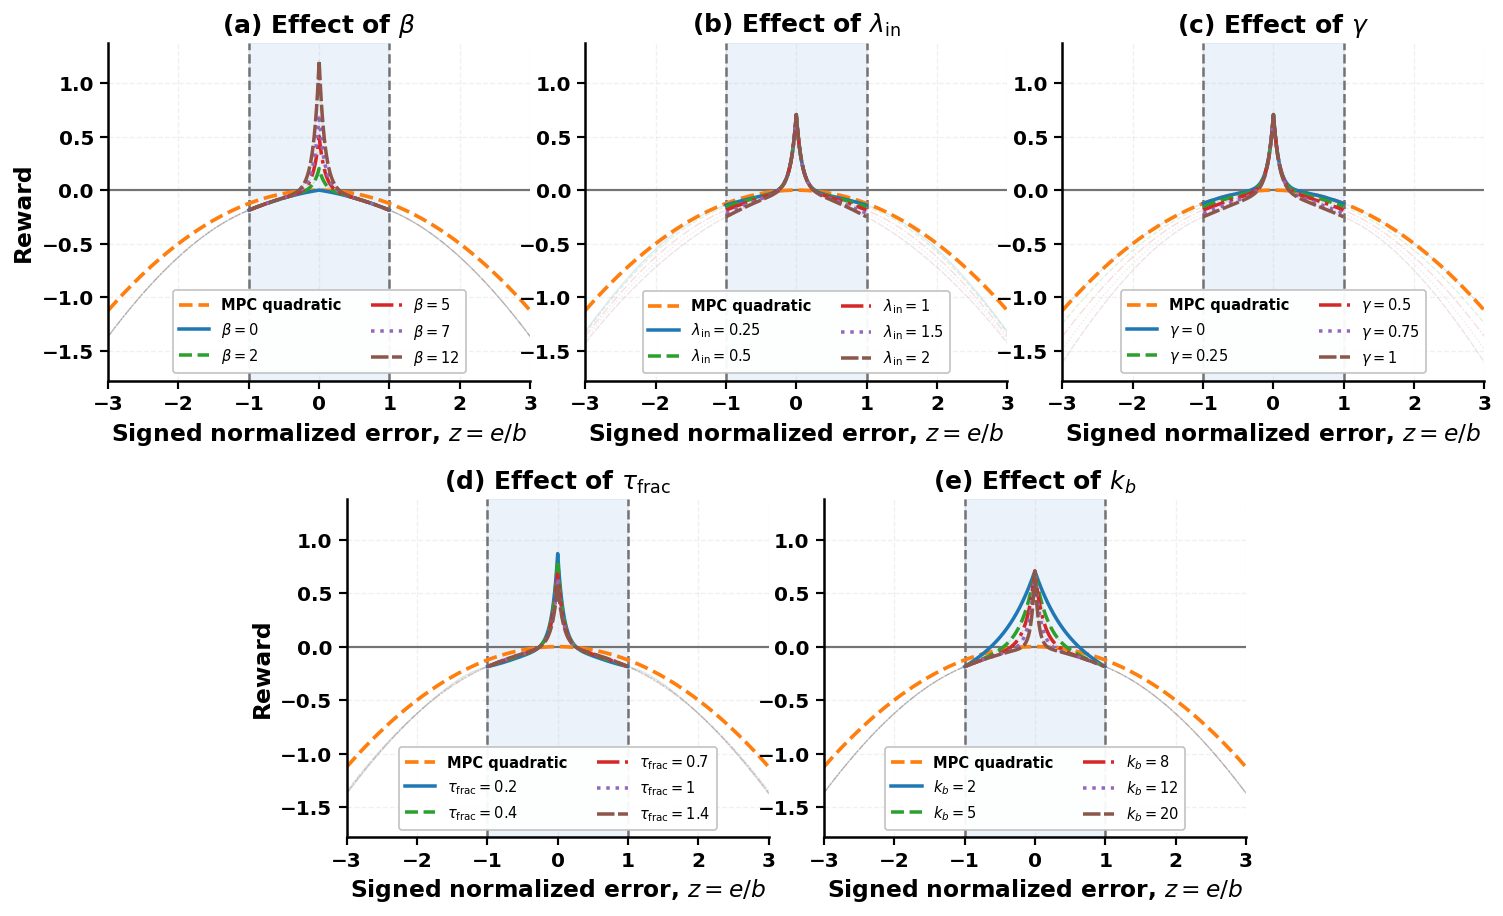

In [180]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


def _eval_reward_curve(reward_fn, z_grid, du_val=0.0):
    z_grid = np.asarray(z_grid, float)
    rewards = np.zeros_like(z_grid)

    for i, z in enumerate(z_grid):
        e_scaled = np.array([z], dtype=float)
        du_scaled = np.array([du_val], dtype=float)
        rewards[i] = reward_fn(e_scaled, du_scaled, y_sp_phys=None)

    return rewards


def _build_unit_band_rewards(
    q_weight=0.125,
    r_weight=0.0,
    tau_frac=0.7,
    gamma_out=0.5,
    gamma_in=0.5,
    beta=7.0,
    lambda_in=1.0,
    k_b=12.0,
    gate="geom",
    bonus_kind="exp",
    bonus_p=0.6,
    bonus_c=20.0
):
    data_min = np.array([0.0, 0.0], dtype=float)
    data_max = np.array([1.0, 1.0], dtype=float)
    n_inputs = 1

    k_rel = np.array([0.0], dtype=float)
    band_floor_phys = np.array([1.0], dtype=float)

    q_diag = np.array([q_weight], dtype=float)
    r_diag = np.array([r_weight], dtype=float)

    _, reward_shaped = make_reward_fn_relative_QR(
        data_min=data_min,
        data_max=data_max,
        n_inputs=n_inputs,
        k_rel=k_rel,
        band_floor_phys=band_floor_phys,
        Q_diag=q_diag,
        R_diag=r_diag,
        tau_frac=tau_frac,
        gamma_out=gamma_out,
        gamma_in=gamma_in,
        beta=beta,
        gate=gate,
        lam_in=lambda_in,
        bonus_kind=bonus_kind,
        bonus_k=k_b,
        bonus_p=bonus_p,
        bonus_c=bonus_c
    )

    _, reward_quadratic = make_reward_fn_mpc_quadratic(
        Q_diag=q_diag,
        R_diag=r_diag
    )

    return reward_shaped, reward_quadratic


def plot_reward_hparam_sensitivity_grid_paper(
    beta_candidates,
    lambda_in_candidates,
    gamma_candidates,
    tau_frac_candidates,
    k_b_candidates,
    q_weight=0.125,
    r_weight=0.0,
    gamma_base=0.5,
    beta_base=7.0,
    lambda_in_base=1.0,
    tau_frac_base=0.7,
    k_b_base=12.0,
    gate="geom",
    bonus_kind="exp",
    bonus_p=0.6,
    bonus_c=20.0,
    z_min=-3.0,
    z_max=3.0,
    n_grid=801,
    figsize=(14.8, 8.6),
    save_path=None,
    save_pdf=False
):
    z_grid = np.linspace(z_min, z_max, n_grid)
    inside_mask = np.abs(z_grid) <= 1.0

    fig = plt.figure(figsize=figsize)

    # Top row: 3 equal panels
    # Bottom row: 2 centered panels
    gs = GridSpec(2, 6, figure=fig, hspace=0.35, wspace=0.30)

    axes = [
        fig.add_subplot(gs[0, 0:2]),  # (a)
        fig.add_subplot(gs[0, 2:4]),  # (b)
        fig.add_subplot(gs[0, 4:6]),  # (c)
        fig.add_subplot(gs[1, 1:3]),  # (d) centered
        fig.add_subplot(gs[1, 3:5])   # (e) centered
    ]

    candidate_colors = ["#1f77b4", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
    candidate_styles = ["-", "--", "-.", ":", (0, (5, 1))]

    panel_specs = [
        {
            "ax": axes[0],
            "title": r"(a) Effect of $\beta$",
            "candidates": beta_candidates,
            "builder": lambda val: _build_unit_band_rewards(
                q_weight=q_weight,
                r_weight=r_weight,
                tau_frac=tau_frac_base,
                gamma_out=gamma_base,
                gamma_in=gamma_base,
                beta=val,
                lambda_in=lambda_in_base,
                k_b=k_b_base,
                gate=gate,
                bonus_kind=bonus_kind,
                bonus_p=bonus_p,
                bonus_c=bonus_c
            ),
            "label": lambda val: rf"$\beta = {val:g}$"
        },
        {
            "ax": axes[1],
            "title": r"(b) Effect of $\lambda_{\mathrm{in}}$",
            "candidates": lambda_in_candidates,
            "builder": lambda val: _build_unit_band_rewards(
                q_weight=q_weight,
                r_weight=r_weight,
                tau_frac=tau_frac_base,
                gamma_out=gamma_base,
                gamma_in=gamma_base,
                beta=beta_base,
                lambda_in=val,
                k_b=k_b_base,
                gate=gate,
                bonus_kind=bonus_kind,
                bonus_p=bonus_p,
                bonus_c=bonus_c
            ),
            "label": lambda val: rf"$\lambda_{{\mathrm{{in}}}} = {val:g}$"
        },
        {
            "ax": axes[2],
            "title": r"(c) Effect of $\gamma$",
            "candidates": gamma_candidates,
            "builder": lambda val: _build_unit_band_rewards(
                q_weight=q_weight,
                r_weight=r_weight,
                tau_frac=tau_frac_base,
                gamma_out=val,
                gamma_in=val,
                beta=beta_base,
                lambda_in=lambda_in_base,
                k_b=k_b_base,
                gate=gate,
                bonus_kind=bonus_kind,
                bonus_p=bonus_p,
                bonus_c=bonus_c
            ),
            "label": lambda val: rf"$\gamma = {val:g}$"
        },
        {
            "ax": axes[3],
            "title": r"(d) Effect of $\tau_{\mathrm{frac}}$",
            "candidates": tau_frac_candidates,
            "builder": lambda val: _build_unit_band_rewards(
                q_weight=q_weight,
                r_weight=r_weight,
                tau_frac=val,
                gamma_out=gamma_base,
                gamma_in=gamma_base,
                beta=beta_base,
                lambda_in=lambda_in_base,
                k_b=k_b_base,
                gate=gate,
                bonus_kind=bonus_kind,
                bonus_p=bonus_p,
                bonus_c=bonus_c
            ),
            "label": lambda val: rf"$\tau_{{\mathrm{{frac}}}} = {val:g}$"
        },
        {
            "ax": axes[4],
            "title": r"(e) Effect of $k_b$",
            "candidates": k_b_candidates,
            "builder": lambda val: _build_unit_band_rewards(
                q_weight=q_weight,
                r_weight=r_weight,
                tau_frac=tau_frac_base,
                gamma_out=gamma_base,
                gamma_in=gamma_base,
                beta=beta_base,
                lambda_in=lambda_in_base,
                k_b=val,
                gate=gate,
                bonus_kind=bonus_kind,
                bonus_p=bonus_p,
                bonus_c=bonus_c
            ),
            "label": lambda val: rf"$k_b = {val:g}$"
        }
    ]

    y_min = np.inf
    y_max = -np.inf

    # First pass to get common y-limits
    for spec in panel_specs:
        candidates = spec["candidates"]
        _, reward_quadratic = spec["builder"](candidates[0])
        r_quad = _eval_reward_curve(reward_quadratic, z_grid)
        y_min = min(y_min, np.min(r_quad))
        y_max = max(y_max, np.max(r_quad))

        for val in candidates:
            reward_shaped, _ = spec["builder"](val)
            r_shaped = _eval_reward_curve(reward_shaped, z_grid)
            y_min = min(y_min, np.min(r_shaped))
            y_max = max(y_max, np.max(r_shaped))

    y_pad = 0.06 * (y_max - y_min)
    y_lim = (y_min - y_pad, y_max + y_pad)

    for spec in panel_specs:
        ax = spec["ax"]
        candidates = spec["candidates"]

        _, reward_quadratic = spec["builder"](candidates[0])
        r_quad = _eval_reward_curve(reward_quadratic, z_grid)

        ax.axvspan(-1.0, 1.0, color="#c7dcef", alpha=0.35, zorder=0)
        ax.axvline(-1.0, color="0.45", linestyle="--", linewidth=1.5)
        ax.axvline(1.0, color="0.45", linestyle="--", linewidth=1.5)
        ax.axhline(0.0, color="0.45", linewidth=1.3)

        ax.plot(
            z_grid,
            r_quad,
            color="#ff7f0e",
            linestyle="--",
            linewidth=2.2,
            label="MPC quadratic",
            zorder=2
        )

        for i, val in enumerate(candidates):
            reward_shaped, _ = spec["builder"](val)
            r_shaped = _eval_reward_curve(reward_shaped, z_grid)

            color = candidate_colors[i % len(candidate_colors)]
            style = candidate_styles[i % len(candidate_styles)]

            # Light full curve for continuity
            ax.plot(
                z_grid,
                r_shaped,
                color=color,
                linestyle=style,
                linewidth=0.8,
                alpha=0.16,
                zorder=1
            )

            ax.plot(
                z_grid[inside_mask],
                r_shaped[inside_mask],
                color=color,
                linestyle=style,
                linewidth=2.1,
                alpha=1.0,
                label=spec["label"](val),
                zorder=3
            )

        ax.set_title(spec["title"], fontweight="bold", fontsize=15)
        ax.set_xlim(z_min, z_max)
        ax.set_ylim(y_lim)
        ax.grid(True, alpha=0.18)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.5)
        ax.spines["bottom"].set_linewidth(1.5)

        ax.tick_params(axis="both", which="major", width=1.3, length=5, labelsize=12)

        ax.legend(
            loc="lower center",
            fontsize=8.8,
            frameon=True,
            ncol=2,
            borderpad=0.4,
            handlelength=2.1
        )

        ax.set_xlabel(r"Signed normalized error, $z = e/b$", fontweight="bold", fontsize=14)

    axes[0].set_ylabel("Reward", fontweight="bold", fontsize=14)
    axes[3].set_ylabel("Reward", fontweight="bold", fontsize=14)

    fig.tight_layout()

    if save_path is not None:
        root, ext = os.path.splitext(save_path)
        if ext.lower() not in [".png", ".pdf"]:
            fig.savefig(root + ".png", dpi=300, bbox_inches="tight")
            if save_pdf:
                fig.savefig(root + ".pdf", bbox_inches="tight")
        else:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
            if save_pdf and ext.lower() != ".pdf":
                fig.savefig(root + ".pdf", bbox_inches="tight")

    return fig, axes


# Example call
beta_candidates = [0.0, 2.0, 5.0, 7.0, 12.0]
lambda_in_candidates = [0.25, 0.50, 1.00, 1.50, 2.00]
gamma_candidates = [0.0, 0.25, 0.50, 0.75, 1.00]
tau_frac_candidates = [0.20, 0.40, 0.70, 1.00, 1.40]
k_b_candidates = [2.0, 5.0, 8.0, 12.0, 20.0]

fig, axes = plot_reward_hparam_sensitivity_grid_paper(
    beta_candidates=beta_candidates,
    lambda_in_candidates=lambda_in_candidates,
    gamma_candidates=gamma_candidates,
    tau_frac_candidates=tau_frac_candidates,
    k_b_candidates=k_b_candidates,
    q_weight=0.125,
    r_weight=0.0,
    gamma_base=0.5,
    beta_base=7.0,
    lambda_in_base=1.0,
    tau_frac_base=0.7,
    k_b_base=12.0,
    z_min=-3.0,
    z_max=3.0,
    save_path="fig_reward_param_sensitivity.png",
    save_pdf=True
)

plt.show()